In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from sklearn.preprocessing import LabelEncoder


In [2]:
df = pd.read_csv("manufacturing_dataset_1000_samples.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Timestamp                   1000 non-null   object 
 1   Injection_Temperature       1000 non-null   float64
 2   Injection_Pressure          1000 non-null   float64
 3   Cycle_Time                  1000 non-null   float64
 4   Cooling_Time                1000 non-null   float64
 5   Material_Viscosity          980 non-null    float64
 6   Ambient_Temperature         980 non-null    float64
 7   Machine_Age                 1000 non-null   float64
 8   Operator_Experience         980 non-null    float64
 9   Maintenance_Hours           1000 non-null   int64  
 10  Shift                       1000 non-null   object 
 11  Machine_Type                1000 non-null   object 
 12  Material_Grade              1000 non-null   object 
 13  Day_of_Week                 1000 n

In [4]:
df.head(10)


,Timestamp,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Shift,Machine_Type,Material_Grade,Day_of_Week,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization,Parts_Per_Hour
0,2023-01-01 00:00:00,221.0,136.0,28.7,13.6,375.5,28.0,3.8,11.2,64,Evening,Type_B,Economy,Thursday,1.625,42.3,0.063,0.510,36.5
1,2023-01-01 01:00:00,213.3,128.9,34.5,14.0,215.8,22.6,6.8,6.3,58,Night,Type_A,Standard,Wednesday,1.655,48.5,0.037,0.389,29.9
2,2023-01-01 02:00:00,222.8,115.9,19.9,9.5,307.0,25.3,4.2,9.6,47,Day,Type_A,Standard,Monday,1.922,29.4,0.061,0.551,56.9
3,2023-01-01 03:00:00,233.3,105.3,39.2,13.1,137.8,26.0,9.2,8.6,49,Evening,Type_A,Premium,Saturday,2.215,52.3,0.054,0.293,31.0
4,2023-01-01 04:00:00,212.2,125.5,45.0,9.9,298.2,23.6,6.2,23.0,49,Night,Type_B,Premium,Monday,1.691,54.9,0.145,0.443,15.0
5,2023-01-01 05:00:00,212.2,120.9,45.0,12.2,192.3,21.5,7.3,25.8,49,Night,Type_A,Standard,Saturday,1.755,57.2,0.162,0.388,15.0
6,2023-01-01 06:00:00,234.0,128.4,21.5,8.8,268.3,18.4,8.5,88.0,60,Day,Type_A,Standard,Wednesday,1.822,30.3,0.513,0.302,63.4
7,2023-01-01 07:00:00,224.2,124.5,27.8,8.0,227.2,24.6,3.8,7.5,52,Evening,Type_A,Standard,Friday,1.800,35.8,0.046,0.550,39.8
8,2023-01-01 08:00:00,209.4,130.7,45.0,11.0,363.6,21.7,3.2,31.8,54,Day,Type_A,Premium,Sunday,1.601,56.0,0.193,0.575,25.4
9,2023-01-01 09:00:00,221.5,107.0,33.9,11.7,188.2,23.7,13.3,52.0,61,Evening,Type_A,Standard,Tuesday,2.071,45.6,0.301,0.078,37.6


In [5]:
df.tail()

,Timestamp,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Shift,Machine_Type,Material_Grade,Day_of_Week,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization,Parts_Per_Hour
995,2023-02-11 11:00:00,211.6,131.1,39.2,10.2,400.0,26.2,10.4,3.3,32,Day,Type_C,Standard,Saturday,1.615,49.5,0.023,0.257,15.0
996,2023-02-11 12:00:00,236.6,114.6,22.8,11.3,348.3,21.2,12.0,67.6,43,Evening,Type_B,Standard,Thursday,2.064,34.2,0.442,0.159,49.6
997,2023-02-11 13:00:00,222.7,101.8,21.5,8.0,254.9,22.7,8.4,57.5,46,Evening,Type_C,Standard,Saturday,2.188,29.5,0.369,0.337,44.2
998,2023-02-11 14:00:00,300.0,112.6,26.7,10.2,122.6,21.1,9.3,120.0,48,Day,Type_A,Standard,Monday,1.849,36.8,0.760,0.291,57.7
999,2023-02-11 15:00:00,221.9,103.8,43.8,13.6,219.6,24.4,3.8,35.1,51,Day,Type_B,Economy,Monday,2.137,57.4,0.218,0.556,21.9


In [6]:
df.describe()

,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization,Parts_Per_Hour
count,1000.000000,1000.000000,1000.00000,1000.00000,980.000000,980.000000,1000.000000,980.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,215.315900,116.075000,35.85170,11.92320,251.630714,22.941224,7.855900,30.795204,50.580000,1.885852,47.737000,0.192688,0.356844,29.298100
std,11.995507,14.667246,8.35349,2.30429,73.348695,2.773712,3.900798,27.684769,16.014558,0.274323,8.671153,0.173839,0.195610,11.955497
min,180.000000,80.000000,16.30000,8.00000,104.600000,18.000000,1.000000,1.000000,26.000000,1.286000,24.600000,0.006000,0.001000,5.000000
25%,207.200000,105.900000,28.80000,10.27500,200.900000,20.800000,4.700000,9.800000,45.000000,1.683750,41.000000,0.061000,0.193000,17.500000
50%,215.300000,115.950000,36.85000,11.90000,242.700000,22.900000,7.900000,22.100000,50.000000,1.849500,48.550000,0.139000,0.355500,28.200000
75%,222.800000,125.925000,45.00000,13.50000,295.300000,25.100000,11.100000,43.425000,55.000000,2.044250,55.300000,0.274000,0.520000,38.000000
max,300.000000,150.000000,60.00000,19.90000,1000.000000,28.000000,15.000000,120.000000,500.000000,2.843000,64.900000,0.840000,0.755000,68.600000


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Injection_Temperature,1000.0,215.315900,11.995507,180.000,207.20000,215.3000,222.80000,300.000
Injection_Pressure,1000.0,116.075000,14.667246,80.000,105.90000,115.9500,125.92500,150.000
Cycle_Time,1000.0,35.851700,8.353490,16.300,28.80000,36.8500,45.00000,60.000
Cooling_Time,1000.0,11.923200,2.304290,8.000,10.27500,11.9000,13.50000,19.900
Material_Viscosity,980.0,251.630714,73.348695,104.600,200.90000,242.7000,295.30000,1000.000
Ambient_Temperature,980.0,22.941224,2.773712,18.000,20.80000,22.9000,25.10000,28.000
Machine_Age,1000.0,7.855900,3.900798,1.000,4.70000,7.9000,11.10000,15.000
Operator_Experience,980.0,30.795204,27.684769,1.000,9.80000,22.1000,43.42500,120.000
Maintenance_Hours,1000.0,50.580000,16.014558,26.000,45.00000,50.0000,55.00000,500.000
Temperature_Pressure_Ratio,1000.0,1.885852,0.274323,1.286,1.68375,1.8495,2.04425,2.843


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df[['Material_Viscosity',
    'Ambient_Temperature',
    'Operator_Experience']].head()

,Material_Viscosity,Ambient_Temperature,Operator_Experience
0,375.5,28.0,11.2
1,215.8,22.6,6.3
2,307.0,25.3,9.6
3,137.8,26.0,8.6
4,298.2,23.6,23.0


In [10]:
df['Material_Viscosity'] = df['Material_Viscosity'].fillna(
    df['Material_Viscosity'].mean()
)

df['Ambient_Temperature'] = df['Ambient_Temperature'].fillna(
    df['Ambient_Temperature'].mean()
)

df['Operator_Experience'] = df['Operator_Experience'].fillna(
    df['Operator_Experience'].mean()
)

In [11]:
df.isnull().sum()

Timestamp                     0
Injection_Temperature         0
Injection_Pressure            0
Cycle_Time                    0
Cooling_Time                  0
Material_Viscosity            0
Ambient_Temperature           0
Machine_Age                   0
Operator_Experience           0
Maintenance_Hours             0
Shift                         0
Machine_Type                  0
Material_Grade                0
Day_of_Week                   0
Temperature_Pressure_Ratio    0
Total_Cycle_Time              0
Efficiency_Score              0
Machine_Utilization           0
Parts_Per_Hour                0
dtype: int64

In [12]:
df.drop("Timestamp", axis=1, inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Injection_Temperature       1000 non-null   float64
 1   Injection_Pressure          1000 non-null   float64
 2   Cycle_Time                  1000 non-null   float64
 3   Cooling_Time                1000 non-null   float64
 4   Material_Viscosity          1000 non-null   float64
 5   Ambient_Temperature         1000 non-null   float64
 6   Machine_Age                 1000 non-null   float64
 7   Operator_Experience         1000 non-null   float64
 8   Maintenance_Hours           1000 non-null   int64  
 9   Shift                       1000 non-null   object 
 10  Machine_Type                1000 non-null   object 
 11  Material_Grade              1000 non-null   object 
 12  Day_of_Week                 1000 non-null   object 
 13  Temperature_Pressure_Ratio  1000 n

In [14]:
df.select_dtypes(include="object").columns

Index(['Shift', 'Machine_Type', 'Material_Grade', 'Day_of_Week'], dtype='object')

In [15]:
le = LabelEncoder()

In [16]:
df["Shift"] = le.fit_transform(df["Shift"])
df["Machine_Type"] = le.fit_transform(df["Machine_Type"])
df["Material_Grade"] = le.fit_transform(df["Material_Grade"])
df["Day_of_Week"] = le.fit_transform(df["Day_of_Week"])

In [17]:
df.head()

,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Shift,Machine_Type,Material_Grade,Day_of_Week,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization,Parts_Per_Hour
0,221.0,136.0,28.7,13.6,375.5,28.0,3.8,11.2,64,1,1,0,4,1.625,42.3,0.063,0.510,36.5
1,213.3,128.9,34.5,14.0,215.8,22.6,6.8,6.3,58,2,0,2,6,1.655,48.5,0.037,0.389,29.9
2,222.8,115.9,19.9,9.5,307.0,25.3,4.2,9.6,47,0,0,2,1,1.922,29.4,0.061,0.551,56.9
3,233.3,105.3,39.2,13.1,137.8,26.0,9.2,8.6,49,1,0,1,2,2.215,52.3,0.054,0.293,31.0
4,212.2,125.5,45.0,9.9,298.2,23.6,6.2,23.0,49,2,1,1,1,1.691,54.9,0.145,0.443,15.0


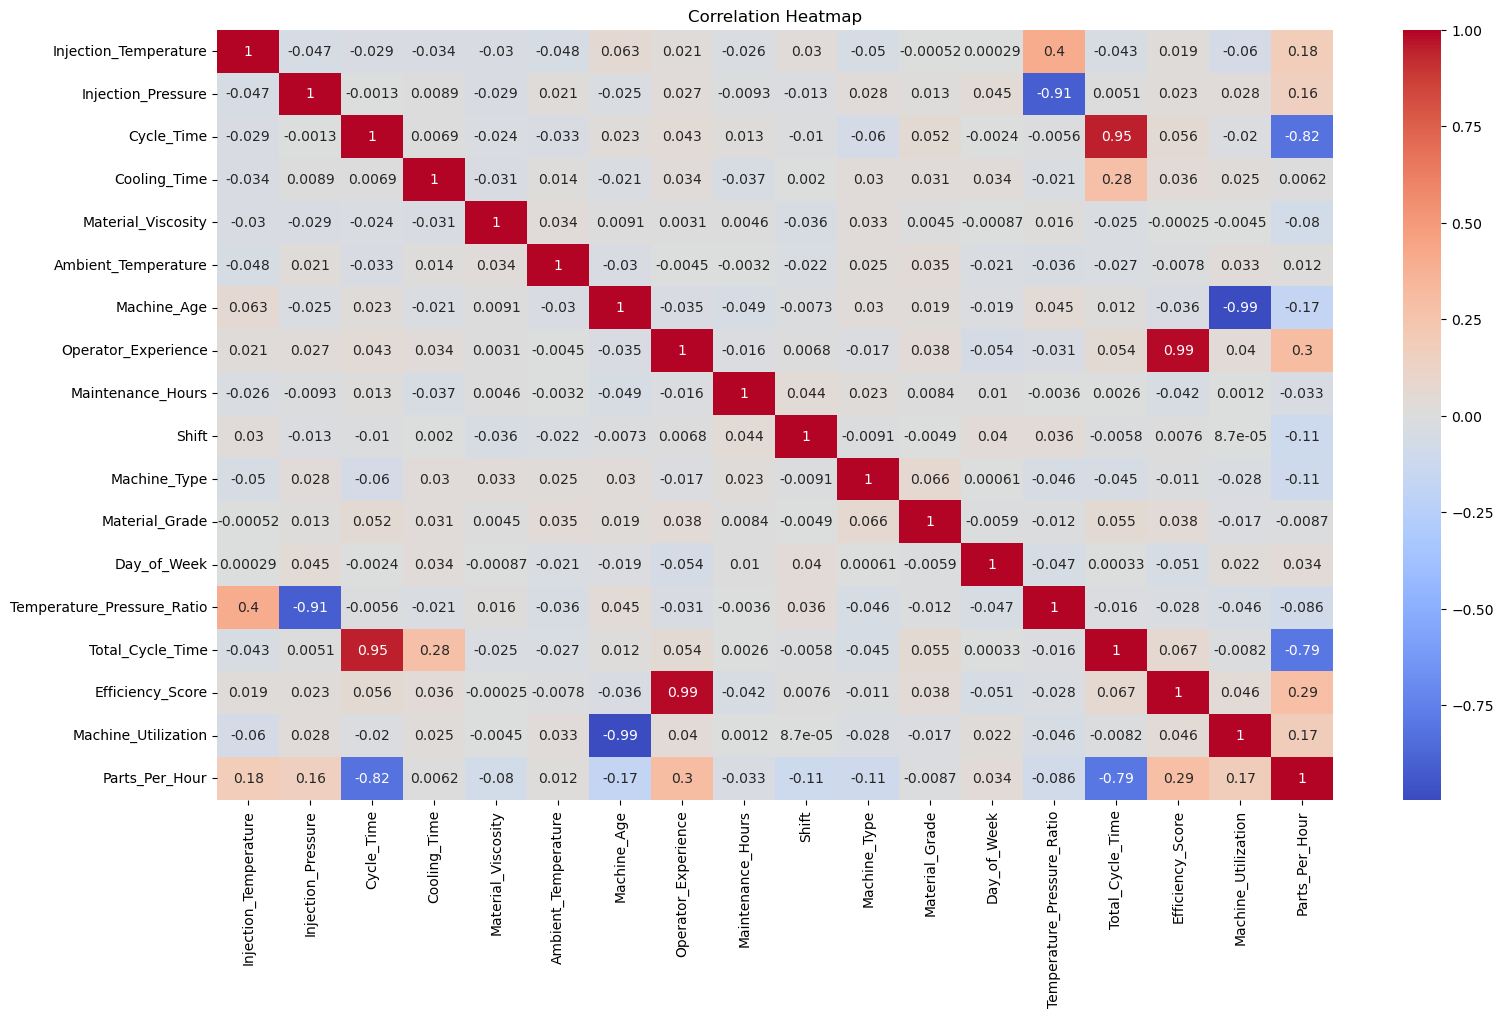

In [18]:
plt.figure(figsize=(18,10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [19]:
df.corr()["Parts_Per_Hour"].sort_values(ascending=False)

Parts_Per_Hour                1.000000
Operator_Experience           0.298895
Efficiency_Score              0.286794
Injection_Temperature         0.184353
Machine_Utilization           0.174573
Injection_Pressure            0.160362
Day_of_Week                   0.034413
Ambient_Temperature           0.011681
Cooling_Time                  0.006215
Material_Grade               -0.008734
Maintenance_Hours            -0.032955
Material_Viscosity           -0.079639
Temperature_Pressure_Ratio   -0.086113
Machine_Type                 -0.105244
Shift                        -0.108241
Machine_Age                  -0.174518
Total_Cycle_Time             -0.792862
Cycle_Time                   -0.819446
Name: Parts_Per_Hour, dtype: float64

In [20]:
X = df.drop("Parts_Per_Hour", axis=1)
y = df["Parts_Per_Hour"]

In [21]:
X.head()

,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Shift,Machine_Type,Material_Grade,Day_of_Week,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization
0,221.0,136.0,28.7,13.6,375.5,28.0,3.8,11.2,64,1,1,0,4,1.625,42.3,0.063,0.510
1,213.3,128.9,34.5,14.0,215.8,22.6,6.8,6.3,58,2,0,2,6,1.655,48.5,0.037,0.389
2,222.8,115.9,19.9,9.5,307.0,25.3,4.2,9.6,47,0,0,2,1,1.922,29.4,0.061,0.551
3,233.3,105.3,39.2,13.1,137.8,26.0,9.2,8.6,49,1,0,1,2,2.215,52.3,0.054,0.293
4,212.2,125.5,45.0,9.9,298.2,23.6,6.2,23.0,49,2,1,1,1,1.691,54.9,0.145,0.443


In [22]:
y.head()

0    36.5
1    29.9
2    56.9
3    31.0
4    15.0
Name: Parts_Per_Hour, dtype: float64

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [24]:
type(X)

numpy.ndarray

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [26]:
print(X_train.shape)
print(X_test.shape)

(800, 17)
(200, 17)


In [27]:
model = LinearRegression()

In [28]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
y_pred = model.predict(X_test)

In [30]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
521,18.6,20.443198
737,42.8,44.896523
740,34.2,32.058345
660,40.0,39.900604
411,15.0,18.209480
678,15.0,18.861178
626,33.6,34.211394
513,15.0,13.883676
859,25.0,28.403946
136,24.2,33.691605


In [31]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score :", r2_score(y_test, y_pred))

MAE : 2.8588910042282123
MSE : 13.71587849071274
RMSE : 3.7034954422427386
R2 Score : 0.8948917238224945


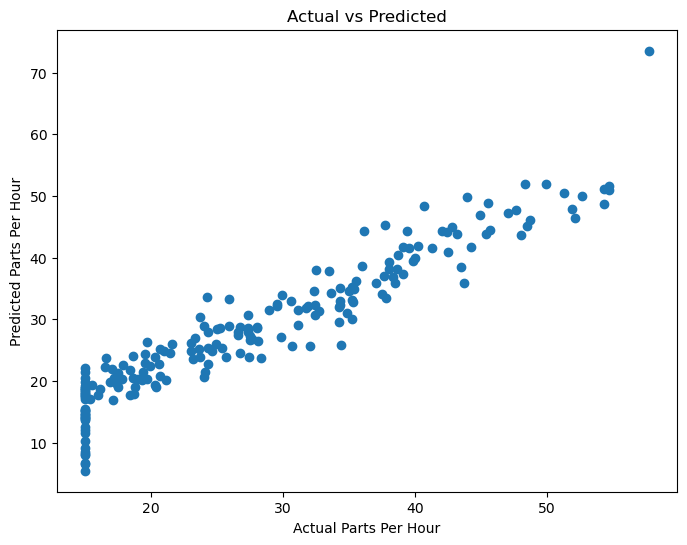

In [32]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Parts Per Hour")
plt.ylabel("Predicted Parts Per Hour")
plt.title("Actual vs Predicted")
plt.show()

In [33]:
print(model.coef_)
print(model.intercept_)

[  2.26471963   1.32206156  -0.52985229   2.68603427  -0.93484103
  -0.10830598  -2.2748553    1.54553159  -0.08864819  -1.54596806
  -1.57587027   0.41003115   0.48598877  -0.74587536 -10.04308915
   2.47588708  -0.44989134]
29.41479427097894


In [34]:
print(sklearn.__version__)

1.7.2


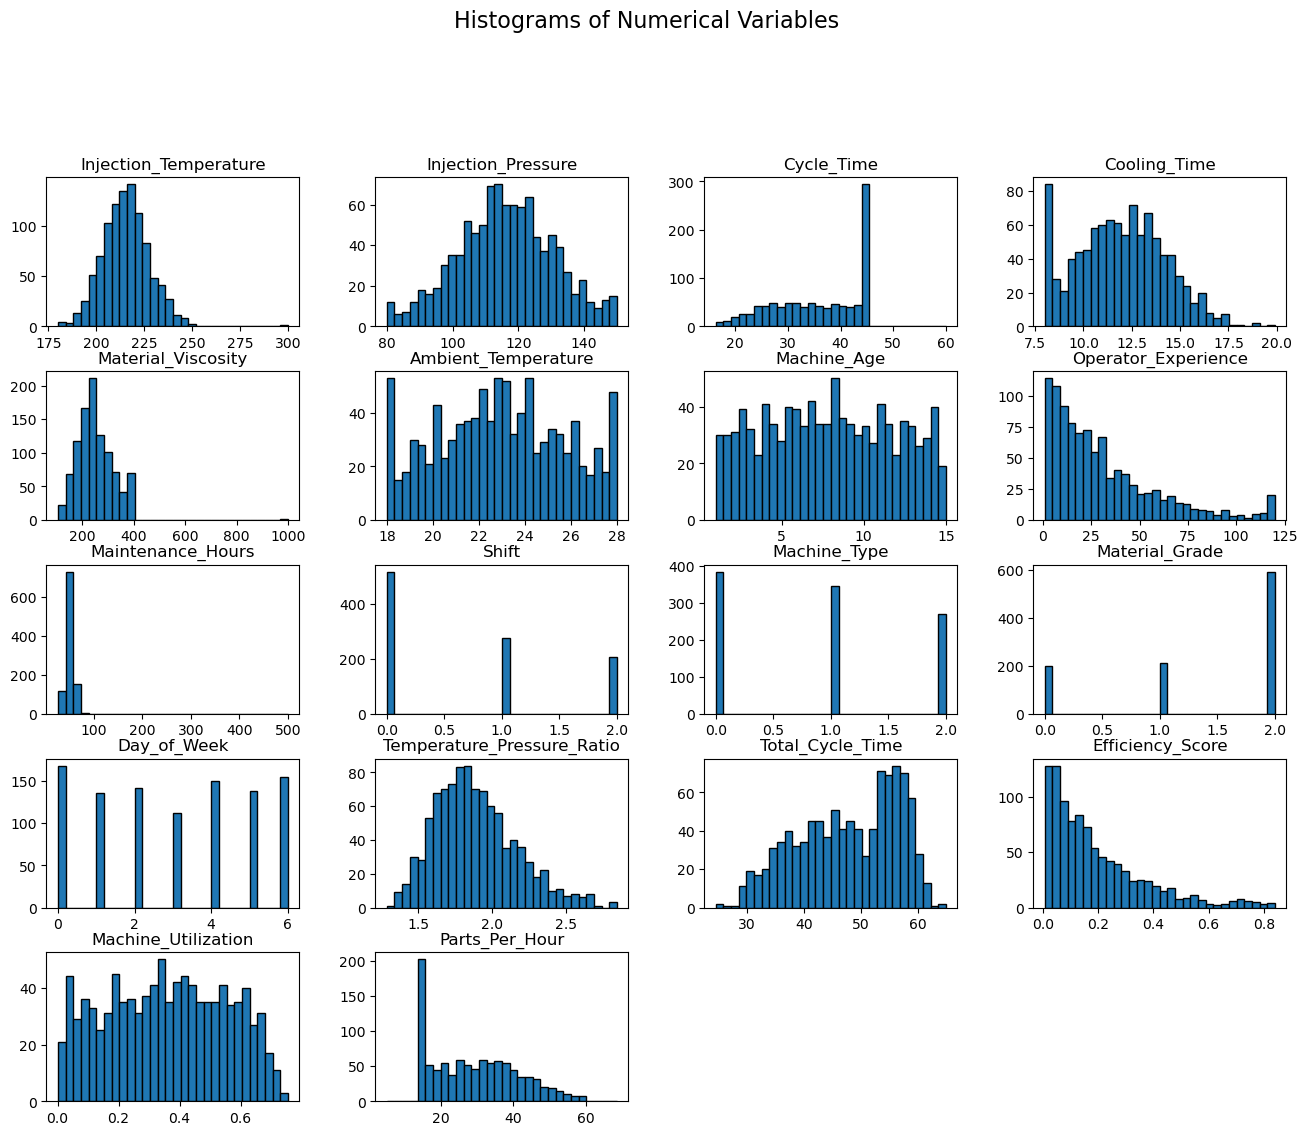

In [35]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

df[numeric_cols].hist(bins=30, figsize=(16, 12), edgecolor='black', grid=False)
plt.suptitle("Histograms of Numerical Variables", fontsize=16, y=1.02)
plt.show()